 ## COPOWER 

 This built-in python code analyses the energy bills from 16096 customers, and trains a machine learning model to forecast  potential cancellations 

## Data Cleaning & Preprocessing 
Establish the relations between DataBases usin joi queries and handle missing values either dropping the columns or using imputation.

In [2]:
import pandas as pd 
import numpy as np 
from sklearn.impute import SimpleImputer

client_df = pd.read_csv("ml_case_training_data.csv")
hist_df = pd.read_csv("ml_case_training_hist_data.csv")
output_df = pd.read_csv("ml_case_training_output.csv")

df = pd.merge(client_df, output_df, on='id')

# Handle missing sales channel
if 'channel_sales' in df: 
    df['channel_sales'] = df['channel_sales'].fillna("Missing")

if 'origin_up' in df :
    df['origin_up'] = df['origin_up'].fillna('Missing')

# Drop high-cardinality date and ID columns immediately to prevent memory explosion
date_cols = ['date_activ', 'date_end', 'date_modif_prod', 'date_renewal', 'date_first_activ']

for col in date_cols : 
    if col in df:
        df[col] = pd.to_datetime(df[col] , errors = 'coerce')


if 'date_end' in df.columns and 'date_activ' in df.columns :
    df['tenure_years'] = (df['date_end'] - df['date_activ'] ).dt.days/365.25 


df = df.drop(columns=[col for col in date_cols if col in df.columns])


# Compute historical price volatility and merge
mean_var = hist_df.groupby('id')[['price_p1_var','price_p2_var','price_p3_var']].mean().reset_index()
mean_var.columns = ['id', 'mean_price_p1_var', 'mean_price_p2_var', 'mean_price_p3_var']

mean_fix = hist_df.groupby('id')[['price_p1_fix', 'price_p2_fix', 'price_p3_fix']].mean().reset_index()
mean_fix.columns = ['id', 'mean_price_p1_fix', 'mean_price_p2_fix', 'mean_price_p3_fix']

df_cleaned = df.merge(mean_var, on='id', how='left').merge(mean_fix, on='id', how='left')
df_cleaned = df_cleaned.dropna( axis = 1, how = "all")

# 4. Handle Skewed Distributions with log1p transformation
skewed_cols = [
    'cons_12m', 'cons_gas_12m', 'cons_last_month', 'forecast_cons_12m', 
    'forecast_cons_year', 'forecast_base_bill_elec', 'forecast_base_bill_year', 
    'forecast_bill_12m', 'forecast_dte_energy_12m', 'forecast_neg_cum_rent_mth', 
    'forecast_price_energy_p1', 'forecast_price_energy_p2', 'forecast_price_p1_fix', 
    'forecast_price_p2_fix', 'forecast_price_p1', 'forecast_price_p2', 'imp_cons', 
    'margin_gross_pow_elec', 'margin_net_pow_elec', 'net_margin', 'pow_max'
]

for col in skewed_cols:
    if col in df_cleaned.columns:
        df_cleaned[col] = np.log1p(df_cleaned[col].clip(lower=0))




 Count the number of missing values at each column. 
 The following criteria is defined : Columns with percentage higher than 50 %  of NaN Values are dropped. For columns below this threshold; the missing values are handled using imputations, whilst specifying "unknown " for categorical columns. 

## Exploratory analysis

Start a completed analysis of the data providen,comparing price distribution, volatility across churn=0 and churn =1 to find the main triggers driving a cancellation 

Compute volatility and spikes ( max - min ) 

Using seaborn, make a matrix correlation to seek the most likely causes of churn

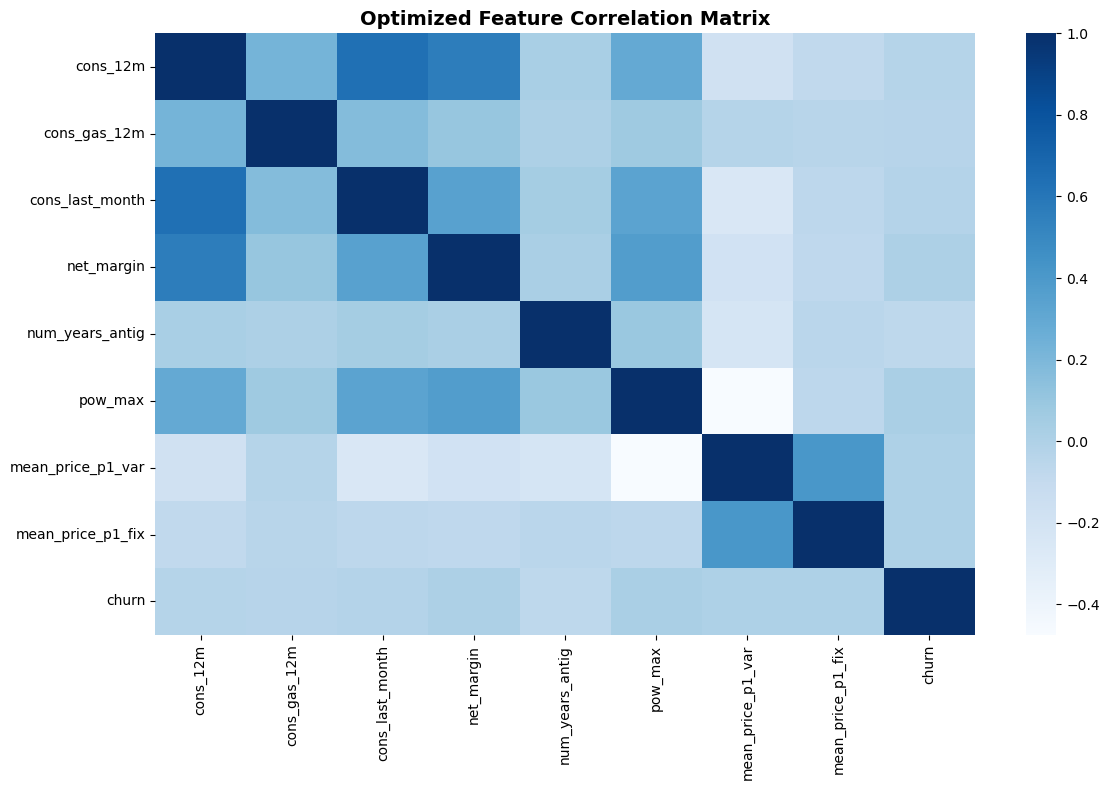

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
core_numerical =  ['cons_12m', 'cons_gas_12m', 'cons_last_month', 'net_margin', 
                 'num_years_antig', 'pow_max', 'mean_price_p1_var', 'mean_price_p1_fix', 'churn']
#Drop 'id' from correlation calculation since it's just a unique identifier

sns.heatmap(df_cleaned[core_numerical].corr(), annot=False, cmap="Blues", fmt=".2f")
plt.title("Optimized Feature Correlation Matrix", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



Genearate continuos plot distributions across the numberical variables to visualize skews and outliers

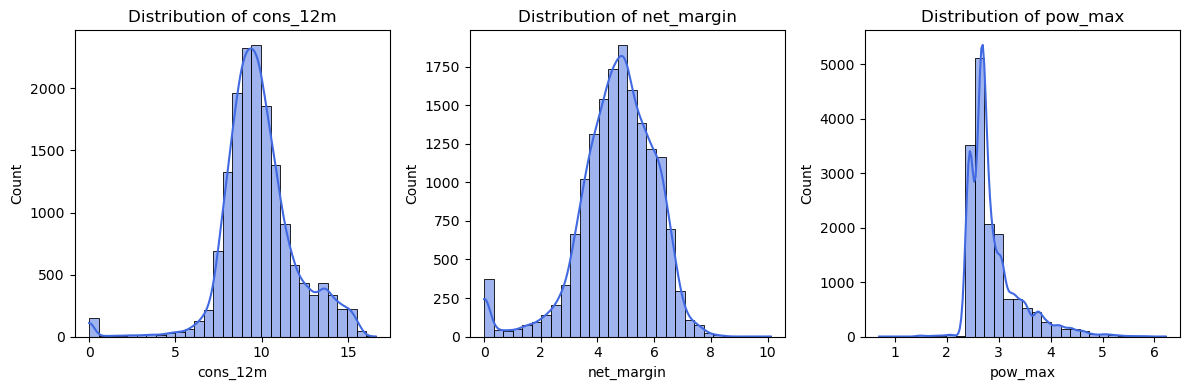

In [4]:
numerical_cols = ['cons_12m' , 'net_margin' , 'pow_max']

plt.figure(figsize=(12, 4))

for i,col in enumerate(numerical_cols , 1):
    plt.subplot(1,3,i)
    sns.histplot(df_cleaned[col].dropna() , kde=True, bins=30, color='royalblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()
    
    

One can visualize that the consumption over 12 months is practically the same for the majority of consumers; it's centered at '. The consumption over the last 12 months and the net_margin are peaked variables, whereas the power max is not as peaked, which can prompt to think to be the trigger cause of churning.

C:\Users\Usuari\AppData\Local\Temp\ipykernel_23832\1238531437.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_cleaned, x='num_years_antig', y='churn', ci=None, palette='viridis')
C:\Users\Usuari\AppData\Local\Temp\ipykernel_23832\1238531437.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_cleaned, x='num_years_antig', y='churn', ci=None, palette='viridis')


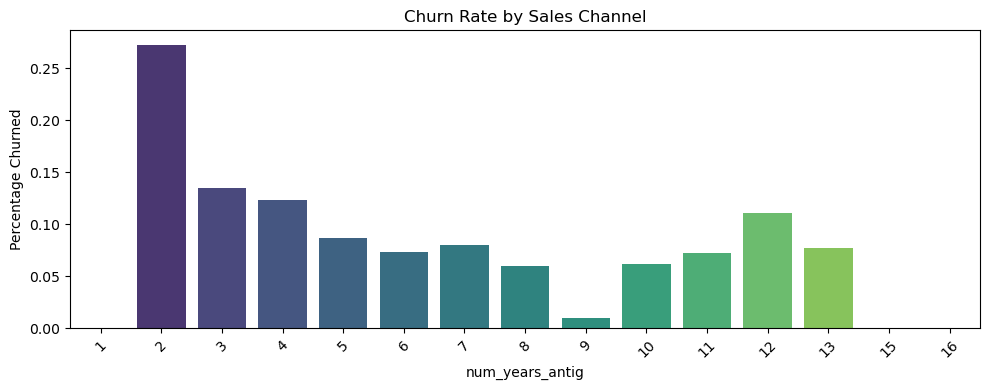

In [5]:


plt.figure(figsize=(10, 4))
sns.barplot(data=df_cleaned, x='num_years_antig', y='churn', ci=None, palette='viridis')
plt.xticks(rotation=45)
plt.title("Churn Rate by Sales Channel")
plt.ylabel("Percentage Churned")
plt.tight_layout()
plt.show()

                      Low Price Spike  High Price Spike
High Tenure (>2 yrs)          0.09118          0.106796
Low Tenure (<=2 yrs)          0.60000          0.000000


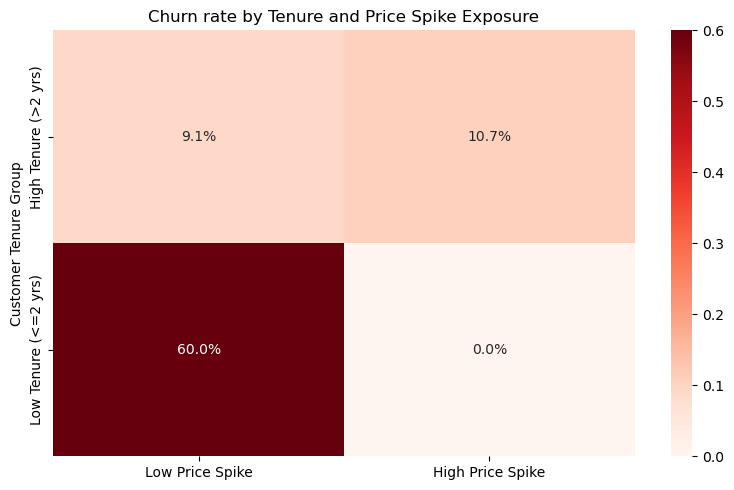

In [5]:

# 1. Compute price_ratio and aggregate per id first to prevent row explosion

for col in ['price_ratio', 'low_tenure', 'high_spike']:
    if col in df_cleaned.columns:
        df_cleaned = df_cleaned.drop(columns=[col])

hist_df['price_ratio'] = hist_df['price_p2_var'] / (hist_df['price_p1_var'] + 1e-5)
agg_price_ratio = hist_df.groupby('id')['price_ratio'].mean().reset_index()

df_cleaned = df_cleaned.merge(agg_price_ratio, on='id', how='left')

# Fill any missing price_ratios introduced by the left join before calculating median
df_cleaned['price_ratio'] = df_cleaned['price_ratio'].fillna(df_cleaned['price_ratio'].median())

# 2. Create binary flags safely
df_cleaned['low_tenure'] = (df_cleaned['num_years_antig'] <= 2).astype(int)
df_cleaned['high_spike'] = (df_cleaned['price_ratio'] > df_cleaned['price_ratio'].median()).astype(int)

pivot_churn = df_cleaned.pivot_table(values='churn', index='low_tenure', columns='high_spike', aggfunc='mean')
pivot_churn.index = ['High Tenure (>2 yrs)', 'Low Tenure (<=2 yrs)']
pivot_churn.columns = ['Low Price Spike', 'High Price Spike']
print(pivot_churn)
plt.figure(figsize=(8, 5))
sns.heatmap(pivot_churn, annot=True, fmt='.1%', cmap='Reds', cbar=True)
plt.title("Churn rate by Tenure and Price Spike Exposure")
plt.ylabel('Customer Tenure Group')
plt.tight_layout()
plt.show()

## Machine Learning &Modelling 

We are now moving to the final stage of the project, where we will apply a Random Forest Classifier to predict whether a subscriber is likely to leave Copower Energy."

In [11]:
from sklearn.model_selection import train_test_split 
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier

df_cleaned= df_cleaned.dropna(subset=['churn'])

X =df_cleaned.drop(columns =['id', 'churn'] , errors = 'ignore').select_dtypes(include=['number'])
Y = df_cleaned['churn']

X_train , X_test, Y_train  , Y_test = train_test_split(X, Y , test_size = 0.2 , random_state = 42 , stratify = Y )

numerical_cols = X_train.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns

# 2. Build a Preprocessing Pipeline to isolate imputation and encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols)
    ]
)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)


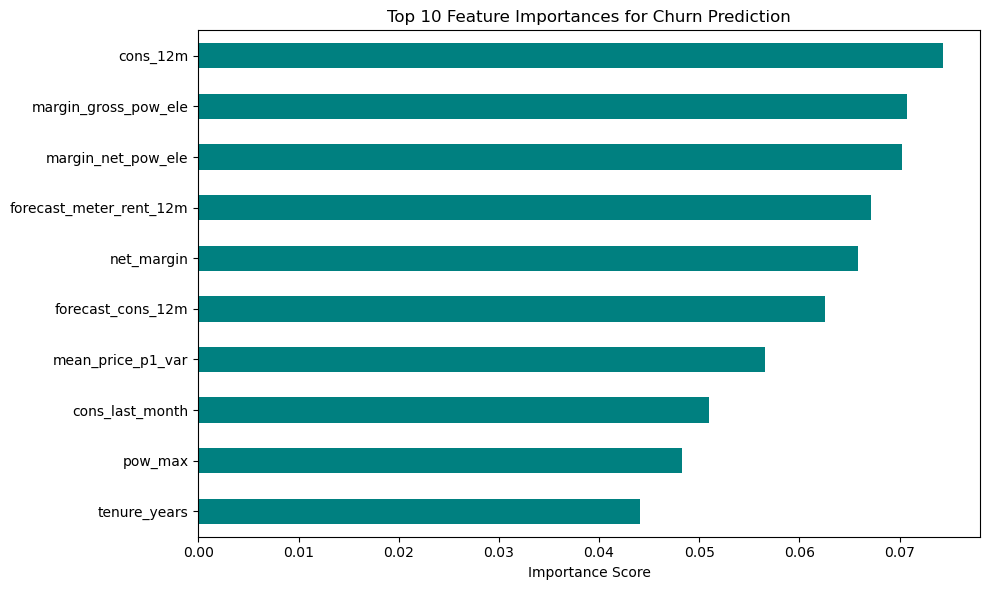

In [10]:


# 4. Train the Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train_processed, Y_train)


importances = pd.Series(rf_model.feature_importances_ , index = X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
importances.head(10).plot(kind = 'barh' , color = 'teal')
plt.title('Top 10 Feature Importances for Churn Prediction')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()  # Put the highest importance at the top
plt.tight_layout()
plt.show()

## Model Validation 

After having  trained a Random Forest   to predict the churning rate , now one evaluates the test set using ROC-AUC .

In [8]:
from sklearn.metrics import roc_auc_score, classification_report

# Predict probabilities for the positive class to calculate ROC-AUC
Y_pred_proba = rf_model.predict_proba(X_test_processed)[:, 1]
roc_auc = roc_auc_score(Y_test, Y_pred_proba)

# Predict discrete classes to generate the classification report
Y_pred = rf_model.predict(X_test_processed)
report = classification_report(Y_test, Y_pred)

print(f"ROC-AUC Score: {roc_auc:.4f}")
print("\nClassification Report:\n", report)

ROC-AUC Score: 0.6763

Classification Report:
               precision    recall  f1-score   support

           0       0.90      1.00      0.95      2901
           1       0.71      0.03      0.06       319

    accuracy                           0.90      3220
   macro avg       0.81      0.51      0.50      3220
weighted avg       0.88      0.90      0.86      3220



The ROC-AUC score indicates that the Random Forest model performs poorly, successfully anticipating only 3% of potential churners. We'll prove a XGboost tree to improve the forecast of potnetial churners. 

## XGBOOST 



In [20]:
from xgboost import XGBClassifier , plot_importance
from sklearn.metrics import roc_auc_score, classification_report

neg_count = np.sum (Y_train ==0 ) 
pos_count =np.sum (Y_train == 1 ) 

scale_weight = neg_count / pos_count 

xgb_model = XGBClassifier( 
    learning_rate = 0.1 , 
    max_depth = 5 , 
    n_estimators = 100 , 
    scale_pos_weight = scale_weight , 
    random_state = 42 )

xgb_model.fit (X_train_processed , Y_train)



,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


## Performance evaluation 

Assess the performanc eof XGboost using accuracy_score and ROC_AUC calculation 

In [18]:
#Accuracy score 
from sklearn.metrics import accuracy_score

#Roc AUC_ SCORE 

Y_pred_proba_xgb = xgb_model.predict_proba(X_test_processed)[:,1]
roc_auc_xgb = roc_auc_score(Y_test , Y_pred_proba_xgb)

Y_pred_xgb= xgb_model.predict(X_test_processed)
report_xgb = classification_report(Y_test, Y_pred_xgb)

print(f"XGBoost ROC-AUC Score: {roc_auc_xgb:.4f}")
print("\nClassification Report:\n", report_xgb)

XGBoost ROC-AUC Score: 0.6845

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.81      0.87      2901
           1       0.22      0.47      0.30       319

    accuracy                           0.78      3220
   macro avg       0.57      0.64      0.58      3220
weighted avg       0.86      0.78      0.81      3220



## Feature importance 

The following plot describes the main features which trigger a chhruning acrossall the customers

In [23]:
import matplotlib.pyplot as plt


# Extract feature importances using 'gain' (measures actual predictive contribution)
importance_dict = xgb_model.get_booster().get_score(importance_type='gain')

named_importance = {
    X_train_processed.columns[int(k.replace('f', ''))]: v 
    for k, v in importance_dict.items()
}

# Convert to a DataFrame
df_importance = pd.DataFrame(list(importance_dict.items()), columns=['Feature', 'Importance'])

# Sort and select only the top 15 features to avoid clutter
df_importance = df_importance.sort_values(by='Importance', ascending=True).tail(15)

# Plot cleanly
plt.figure(figsize=(10, 6))
plt.barh(df_importance['Feature'], df_importance['Importance'], color='#2b5c8f')
plt.xlabel('Average Gain (Predictive Impact)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Top 15 XGBoost Feature Importances', fontsize=14, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

AttributeError: 'numpy.ndarray' object has no attribute 'columns'